In [2]:
import pandas as pd

In [4]:
data = pd.read_excel('PL - Age + Minutes Data.xlsx')

In [5]:
data = data.dropna(subset = ['Age'])

In [6]:
data = data.fillna(0)

In [7]:
data.head()

,Player,Squad,Age,Min
0,Max Aarons,Bournemouth,25.0,86.0
1,Zach Abbott,Nott'ham Forest,18.0,0.0
2,Joshua Acheampong,Chelsea,18.0,90.0
3,Tyler Adams,Bournemouth,25.0,506.0
4,Tosin Adarabioyo,Chelsea,27.0,623.0


In [8]:
num_obs = 20

In [10]:
minutes_model = pd.DataFrame()

In [16]:
import numpy as np
minutes_model = minutes_model.assign(minutes = data['Min'][0:num_obs])
minutes_model = minutes_model.assign(age = data['Age'][0:num_obs])
minutes_model = minutes_model.assign(age_squared = np.power(data['Age'],2))

In [17]:
import statsmodels.formula.api as smf

In [19]:
model_fit=smf.ols(formula='minutes  ~ age + age_squared  ', data=minutes_model).fit()

In [20]:
print(model_fit.summary())

                            OLS Regression Results                            
Dep. Variable:                minutes   R-squared:                       0.376
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     5.112
Date:                Tue, 11 Feb 2025   Prob (F-statistic):             0.0183
Time:                        22:00:03   Log-Likelihood:                -150.94
No. Observations:                  20   AIC:                             307.9
Df Residuals:                      17   BIC:                             310.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -5599.1867   3930.269     -1.425      

In [21]:
b=model_fit.params

In [22]:
import matplotlib.pyplot as plt

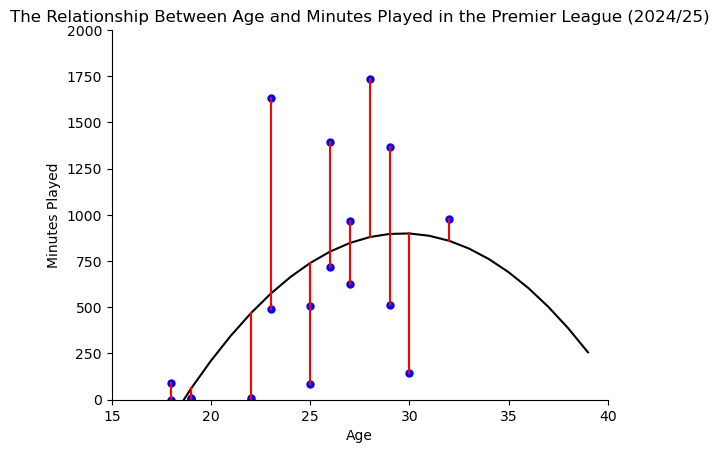

In [30]:
fig,ax=plt.subplots(num=1)
ax.plot(minutes_model['age'], minutes_model['minutes'], linestyle='none', marker= '.', markersize= 10, color='blue')
ax.set_ylabel('Minutes Played')
ax.set_xlabel('Age')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlim((15,40))
plt.ylim((-1,2000))
plt.title('The Relationship Between Age and Minutes Played in the Premier League (2024/25)')
x=np.arange(40,step=1)
y= b[0] + b[1]*x + b[2]*x*x
ax.plot(x, y, color='black')

for i,a in enumerate(minutes_model['age']):
    ax.plot([a,a],[minutes_model['minutes'][i], b[0] + b[1]*a + b[2]*a*a], color='red')
plt.show()